# S&P500

In [ ]:
# imports
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

import sys
import os
sys.path.append(os.path.abspath("..")) 

from functions.adf_v2 import ADF_test_v2

ModuleNotFoundError: No module named 'statsmodels'

### Analysis of S&P500 using ADF, SADF, GSADF, BSADF from 1990-2026

First we download data from Yahoo Finance.

In [9]:
# download data in monthly intervals (otherwise recursive tests are too slow on such a long period)
sp500 = yf.Ticker("^GSPC").history(start="1990-01-01", interval="1mo")

/Users/emilrand/Library/Python/3.12/lib/python/site-packages/yfinance/scrapers/history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/Users/emilrand/Library/Python/3.12/lib/python/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


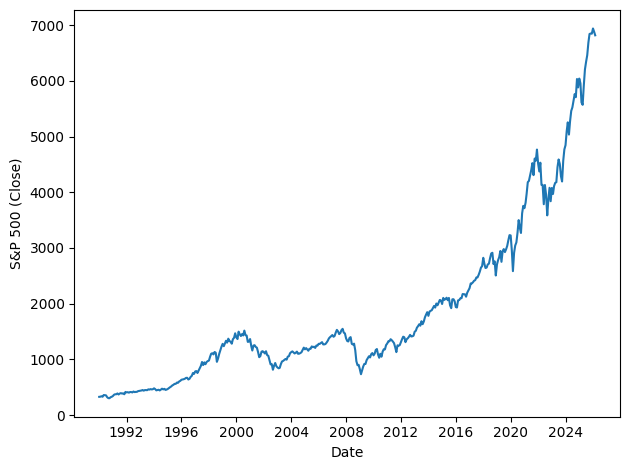

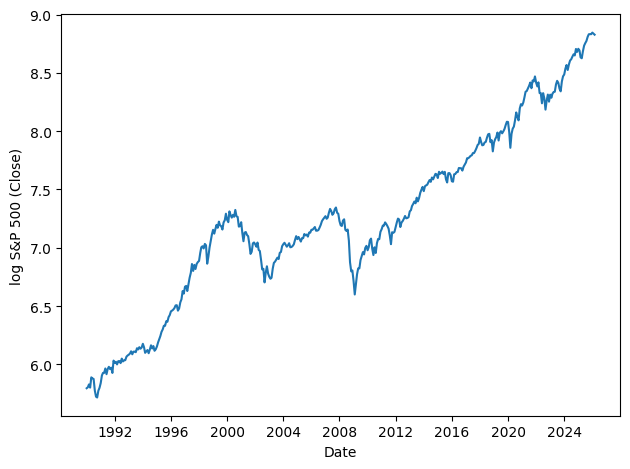

In [22]:
plt.plot(sp500.index, sp500["Close"])
plt.xlabel("Date")
plt.ylabel("S&P 500 (Close)")
plt.tight_layout()
plt.show()

# log
log_sp500 = np.log(sp500["Close"])

plt.plot(log_sp500.index, log_sp500)
plt.xlabel("Date")
plt.ylabel("log S&P 500 (Close)")
plt.tight_layout()
plt.show()

Gem data

In [5]:
log_sp500.to_csv("../data/log_sp500.csv", index_label="t") 

Data er nu behandler i .R filen. Nu plottes BSADF test og kritiske værdier.

In [12]:
# 1. Load data
log_sp500   = pd.read_csv("../data/log_sp500.csv")          # has full date index
bsadf_stat  = pd.read_csv("../data/sp500_bsadf_stat.csv")   # column: 'bsadf'
bsadf_cv    = pd.read_csv("../data/sp500_bsadf_cv.csv")     # columns: '90%', '95%', '99%'

In [14]:
# 2. Align dates with BSADF series length
T_full = len(log_sp500)
T_b    = len(bsadf_stat)
start  = T_full - T_b                      # drop the first 'start' dates

dates = pd.to_datetime(log_sp500["t"], utc=True).dt.tz_convert(None).iloc[start:]

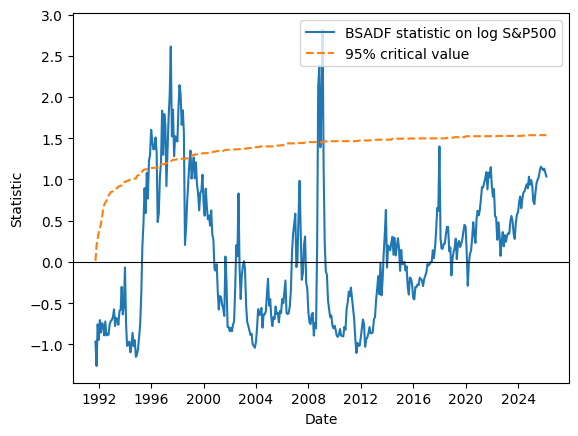

In [16]:
plt.plot(dates, bsadf_stat["bsadf"], label="BSADF statistic on log S&P500")
plt.plot(dates, bsadf_cv["95%"], label="95% critical value", linestyle="--")
plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Date")
plt.ylabel("Statistic")
plt.legend()

### ADF using the v2

In [27]:
# Run ADF test on log S&P500
adf_stat, adf_cv = ADF_test(log_sp500.to_numpy(), lags=0, trend="c")

print("ADF statistic:", adf_stat)
print("Critical values:")
for k, v in adf_cv.items():
    print(f"  {k}: {v}")

NameError: name 'ADF_test' is not defined